In [12]:
# Questo notepad è documentato sul drive nel file "Predizione appartenenza AD/PD"
# Qui vengono eseguiti i seguenti task
# - Ottenimento degli embeddings da anc2vec utilizzando l'ultima versione delle go.
# - Costruzione dei tensori da dare in input al modello GCN
# Requirements per questo notepad:
# - Python 3.6
# - Tensorflow 2.3.1

"""
This notebook is responsible for embedding Gene Ontology data using the anc2vec module 
 and producing intermediate data representations in CSV format. 
 These representations will be further processed in other notebooks 
 or used directly as training data for models
"""

import pandas as pd
import numpy as np
import anc2vec

In [13]:
"""
This cell is used to train anc2vec model on new data.
Not useful now, it will remain commented
""" 

# import anc2vec.train as builder

# NOTE: it's intensive
# go_obo_path = ... [obo file]
# anc2vec_embeddings = builder.fit(go_obo_path, embedding_sz=200, batch_sz=64, num_epochs=100)

'\nThis cell is used to train anc2vec model on new data.\nNot useful now, it will remain commented\n'

In [14]:
embeddings = anc2vec.get_embeddings()

In [15]:
AD_nodes_path = '../networks/AD_nodes.csv'
PD_nodes_path = '../networks/PD_nodes.csv'
AD_edges_path = '../networks/AD_edges.csv'
PD_edges_path = '../networks/PD_edges.csv'

def merge_embeddings(go_list, go_to_embeddings):
    """
    Aggregates embeddings by summing the vectors instead of averaging.
    """
    embeddings = [go_to_embeddings[g.strip()] for g in go_list if g in go_to_embeddings]
    
    if not embeddings:  # If the list is empty, return a null embedding with the same dimension
        return np.zeros_like(next(iter(go_to_embeddings.values()))).tolist()

    return np.sum(embeddings, axis=0).tolist()  # Sum of the vectors


def embed_gos(nodes_path):
    """
    Outputs a dataframe associating each protein (STRING id) with its feature vector (anc2vec embedding).
    """
    nodes_df = pd.read_csv(nodes_path)[['name', 'Gene Ontology IDs']]
    unique_go_ids = set(id.strip() for ids in nodes_df['Gene Ontology IDs'].str.split(';') for id in ids)
    go_to_embeddings = {go:embeddings[go] for go in unique_go_ids if go in embeddings}

    # Aggregates all GO terms for each record
    nodes_df['Gene Ontology IDs'] = nodes_df['Gene Ontology IDs'].apply(
        lambda x: merge_embeddings([go.strip() for go in x.split(';')], go_to_embeddings)
    )

    nodes_df.columns = ['STRING_id', 'GO_embeddings']
    return nodes_df

def edges_map(edges_path):
    """
    Outputs a dataframe where each pair of proteins (STRING id) represents an edge between them.
    """
    raw_edges_df = pd.read_csv(edges_path)['name']

    edges_df = raw_edges_df.str.extract(r'(\S+) \(interacts with\) (\S+)')
    edges_df.columns = ['node1', 'node2']

    return edges_df

def merge_datasets(df1, df2):
    """
    Combines the two input datasets, assigning label 2 to shared records.
    """
    df_combined = pd.concat([df1, df2], ignore_index=True)
    df_combined["label"] = df_combined.groupby("STRING_id")["label"].transform(lambda x: 2 if len(x) > 1 else x)
    df_final = df_combined.drop_duplicates(subset=["STRING_id"]).reset_index(drop=True)

    return df_final


# 1. Replace GO terms with embeddings
AD_embedded_df = embed_gos(AD_nodes_path)
PD_embedded_df = embed_gos(PD_nodes_path)

# 2. Create edge mappings
AD_edges = edges_map(AD_edges_path)
PD_edges = edges_map(PD_edges_path)

# 3. Apply label (0 = AD, 1 = PD, 2 = shared)
AD_embedded_df['label'] = 0
PD_embedded_df['label'] = 1

# 4. Merge AD, PD
merged_embedded_df = merge_datasets(AD_embedded_df, PD_embedded_df)

# 5. Map STRING id to numeric id
node_names = list(set(AD_embedded_df['STRING_id'].to_list() + PD_embedded_df['STRING_id'].to_list()))
prot_name_to_id = {node: i for i, node in enumerate(node_names)}

merged_embedded_df['num_id'] = merged_embedded_df['STRING_id'].map(prot_name_to_id)
AD_edges['num_id_1'] = AD_edges['node1'].map(prot_name_to_id)
AD_edges['num_id_2'] = AD_edges['node2'].map(prot_name_to_id)
PD_edges['num_id_1'] = PD_edges['node1'].map(prot_name_to_id)
PD_edges['num_id_2'] = PD_edges['node2'].map(prot_name_to_id)

AD_embedded_df.head()


,STRING_id,GO_embeddings,label
0,9606.ENSP00000272638,"[1.972828984260559, 0.5850759744644165, 1.6848...",0
1,9606.ENSP00000240587,"[1.520505666732788, -0.06534484028816223, 1.68...",0
2,9606.ENSP00000464391,"[1.2079392671585083, 0.14552484452724457, 0.79...",0
3,9606.ENSP00000262629,"[5.751279830932617, 2.535179853439331, -1.4905...",0
4,9606.ENSP00000216484,"[1.0493078231811523, -1.3144572973251343, 1.02...",0


In [16]:
# This cell transforms the dataset for different tasks.

label_mapping = {
    0: (1, 0),      # AD
    1: (0, 1),      # PD
    2: (1, 1)       # AD ^ PD
}

multilabel_df = merged_embedded_df.copy()
multilabel_df['label'] = multilabel_df['label'].map(label_mapping)

multilabel_df.to_csv('../pre_processing_output/multi_label_nodes.csv')
merged_embedded_df.to_csv('../pre_processing_output/classification_three_labels_nodes.csv')
egdes_combined = pd.concat([AD_edges, PD_edges], ignore_index=True)
edges_combined = egdes_combined.drop_duplicates(subset=['node1', 'node2']).reset_index(drop=True)

edges_combined.to_csv('../pre_processing_output/edges.csv')

# Here the transformations for the binary classification task with duplicated shared nodes take place
# -------- Edge duplication

# 1. Find shared nodes (edge endpoints)
nodes_AD = set(AD_edges['num_id_1']).union(set(AD_edges['num_id_2']))
nodes_PD = set(PD_edges['num_id_1']).union(set(PD_edges['num_id_2']))
common_nodes = nodes_AD.intersection(nodes_PD)

# 2. Add "_AD" or "_PD" to shared nodes based on their source
# 3. Make PD protein ids negative
def modify_common_nodes(df, suffix):
    df = df.copy()
    df.loc[df['num_id_1'].isin(common_nodes), 'node1'] += f'_{suffix}'
    df.loc[df['num_id_2'].isin(common_nodes), 'node2'] += f'_{suffix}'
    
    return df

AD_edges_mod = modify_common_nodes(AD_edges, 'AD')
PD_edges_mod = modify_common_nodes(PD_edges, 'PD')

# 3. Concatenate
duplicated_edges = pd.concat([AD_edges_mod, PD_edges_mod], ignore_index=True)


# ------ Node duplication

df = merged_embedded_df.copy()

# 1. Filter records with label = 2
df_label_2 = df[df['label'] == 2]

# 2. Create the _AD version
df_ad = df_label_2.copy()
df_ad['STRING_id'] = df_ad['STRING_id'] + '_AD'
df_ad['label'] = 0

# 3. Create the _PD version
df_pd = df_label_2.copy()
df_pd['STRING_id'] = df_pd['STRING_id'] + '_PD'
df_pd['label'] = 1

# 4. Remove original records with label = 2
df = df[df['label'] != 2]

# 5. Concatenate the updated dataset with the new versions
duplicated_nodes = pd.concat([df, df_ad, df_pd], ignore_index=True)

# ------- Reassign numeric ids for duplicated nodes (consistency between nodes and edges)

"""
max_id = duplicated_nodes['num_id'].max()
df_pd = duplicated_nodes[duplicated_nodes['STRING_id'].str.endswith('_PD')].copy()
df_pd['num_id'] = range(max_id + 1, max_id + 1 + len(df_pd))
duplicated_nodes.update(df_pd)
duplicated_nodes['num_id'] = duplicated_nodes['num_id'].astype(int)
duplicated_nodes['label'] = duplicated_nodes['label'].astype(int)


duplicated_nodes.to_csv('../pre_processing_output/duplicated_nodes.csv')"""

to_change_id = duplicated_nodes[duplicated_nodes['STRING_id'].str.endswith('_PD')]['STRING_id'].to_list()
max_id = duplicated_nodes['num_id'].max()
to_change_map = {value : key + max_id + 1 for key, value in enumerate(to_change_id)}

duplicated_nodes['num_id'] = duplicated_nodes['STRING_id'].map(to_change_map).fillna(duplicated_nodes['num_id'])
duplicated_edges['num_id_1'] = duplicated_edges['node1'].map(to_change_map).fillna(duplicated_edges['num_id_1'])
duplicated_edges['num_id_2'] = duplicated_edges['node2'].map(to_change_map).fillna(duplicated_edges['num_id_2'])

duplicated_edges.to_csv('../pre_processing_output/duplicated_edges.csv')
duplicated_nodes.to_csv('../pre_processing_output/duplicated_nodes.csv')

common_dup_protein_ids = set(duplicated_nodes[duplicated_nodes['STRING_id'].str.contains('_PD') | duplicated_nodes['STRING_id'].str.contains('_AD')]['num_id'].to_list())
import pickle
with open('../pre_processing_output/common_duplicated_protein_id.pkl', 'wb') as f:
    pickle.dump(common_dup_protein_ids, f)

Number of nodes: 191
Number of edges: 680


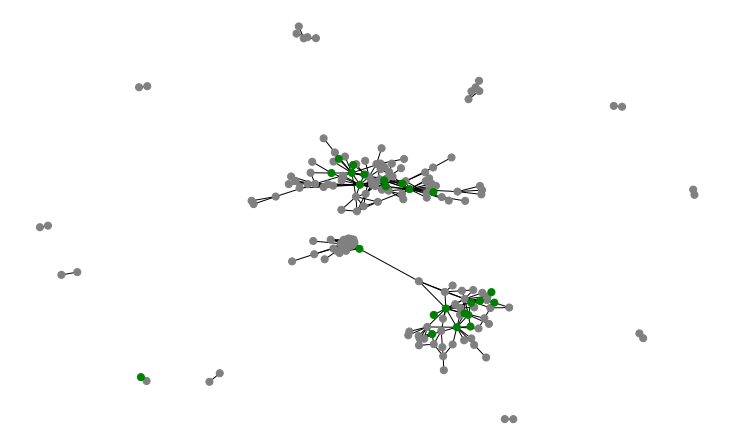

In [17]:
import pandas as pd
import networkx as nx

# Load the datasets (if not already in pandas)
# duplicated_nodes = pd.read_csv("path_to_duplicated_nodes.csv")  # If you have a CSV
# duplicated_edges = pd.read_csv("path_to_duplicated_edges.csv")

# Create the graph
G = nx.Graph()

# Add nodes with the 'label' feature
for _, row in duplicated_nodes.iterrows():
    G.add_node(row["STRING_id"], label=row["label"])

# Add edges based on 'STRING_id' from the duplicated_edges dataset
for _, row in duplicated_edges.iterrows():
    G.add_edge(row["node1"], row["node2"])

# Check
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

import matplotlib.pyplot as plt

# Create a color map for nodes: green for label 2 (duplicated), gray for others
node_colors = ["green" if "_" in n else "gray" for n in G.nodes]

plt.figure(figsize=(10, 6))
nx.draw(G, node_size=50, font_size=8, node_color=node_colors)
plt.show()

In [18]:
# Exclude proteins belonging to smaller connected components (not part of the large AD and PD groups)
# IMPORTANT: these are mostly Alzheimer-related proteins

# 1. Get the connected components
l = [component for component in nx.connected_components(G)]
l = sorted(l, key=len, reverse=True)

# 2. Get the proteins belonging to the smaller connected components
disconnected_components_prots = set()
for c in l[2:]:
    disconnected_components_prots.update(c)

# 3. Exclude them from the node dataset

duplicated_nodes_main_components = duplicated_nodes.copy()
duplicated_nodes_main_components = duplicated_nodes_main_components[~duplicated_nodes_main_components['STRING_id'].isin(disconnected_components_prots)]

# 4. Exclude the edges connecting these to others

duplicated_edges_main_components = duplicated_edges.copy()
duplicated_edges_main_components = duplicated_edges_main_components[~duplicated_edges_main_components['node1'].isin(disconnected_components_prots)]
duplicated_edges_main_components = duplicated_edges_main_components[~duplicated_edges_main_components['node2'].isin(disconnected_components_prots)]

# Reset indices
all_remaining_prots_to_id = {name:index for index, name in enumerate(duplicated_nodes_main_components['STRING_id'].to_list())}
duplicated_nodes_main_components['num_id'] = duplicated_nodes_main_components['STRING_id'].map(all_remaining_prots_to_id)
duplicated_edges_main_components['num_id_1'] = duplicated_edges_main_components['node1'].map(all_remaining_prots_to_id)
duplicated_edges_main_components['num_id_2'] = duplicated_edges_main_components['node2'].map(all_remaining_prots_to_id)

# 5. Output

duplicated_nodes_main_components.to_csv('../pre_processing_output/duplicated_nodes_main_components.csv')
duplicated_edges_main_components.to_csv('../pre_processing_output/duplicated_edges_main_components.csv')

print(len(duplicated_nodes_main_components))


163


In [19]:
classif = pd.read_csv('../pre_processing_output/classification_three_labels_nodes.csv')

disconnected_components_prots = set([x.split('_')[0] for x in disconnected_components_prots])
classif = classif[~classif['STRING_id'].isin(disconnected_components_prots)]
classif = classif.rename(columns={'Unnamed: 0': 'id'})
classif.to_csv('../pre_processing_output/classification_three_labels_nodes_main_components.csv')

# Serialize minor component's proteins for further filtering in other notepads
import pickle as pkl
with open('../pre_processing_output/minor_components_prots.pkl', 'wb') as out:
    pkl.dump(disconnected_components_prots, out)
